In [9]:
import os
import glob
import pandas as pd

In [14]:
mp, trans = 0, []
# this strategy works for BTC!!!!
for file in sorted(glob.glob('../../../data/BTCEUSD_PERP/*.csv')):
    df = pd.read_csv(file)
    round_at = 1 if 'BTC' in file else 5
    upp = round(df.open[0] * 1.03, round_at)
    dnn = round(df.open[0] * 0.97, round_at)
    mp = 0 # 
    for i in range(df.shape[0] - 1):
        if mp == 0 and df.iloc[i]['high'] >= upp:
            mp = 1
            enpp = upp
        if mp == 0 and df.iloc[i]['low'] <= dnn:
            mp = -1
            enpp = dnn
    trans.append([mp, enpp, df.iloc[i+1]['open']])
            


,Unnamed: 0,pos,open,close,close_t
0,0,1,0.085870,0.083898,1.674245e+12
1,1,1,0.085920,0.084486,1.674245e+12
2,2,-1,0.084270,0.088311,1.674297e+12
3,3,1,0.090730,0.089742,1.674406e+12
4,4,1,0.090883,0.090670,1.674406e+12


In [34]:
mp, trans = 0, []
for file in sorted(glob.glob('../../../data/DOGEUSD_PERP/*.csv')):
    df = pd.read_csv(file)
    round_at = 1 if 'BTC' in file else 5
    dopen = df.open[0]
    upp = round(dopen * 1.03, round_at)
    dnn = round(dopen * 0.97, round_at)
    for i in range(df.shape[0] - 1):
        if mp <= 0 and df.iloc[i]['high'] >= upp:
            price = max(dopen, upp)
            # if mp < 0:
            #    trans.append([mp, enpp, price]) 
            mp = 1
            enpp = price
        if mp >= 0 and df.iloc[i]['low'] <= dnn:
            price = min(dopen, dnn)
            # if mp > 0:
            #    trans.append([mp, enpp, price]) 
            mp = -1
            enpp = dnn
    if mp:
        trans.append([mp, enpp, df.iloc[i+1]['open']])
        # mp = 0

423    0.566774
424    0.587004
425    0.609634
426    0.617675
427    0.641285
dtype: float64


<AxesSubplot:>

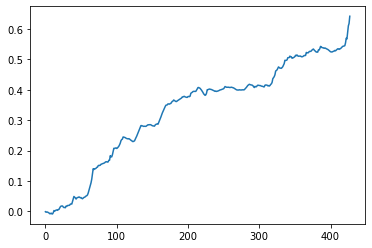

In [35]:
rcd = pd.DataFrame(trans, columns=['pos', 'open', 'close'])
profit = rcd.pos * (rcd.close - rcd.open)
commis = rcd.pos.abs() * (rcd.close + rcd.open) * 0.0005
res = (profit + 1 * commis).cumsum()
print(res.tail())
res.plot()